## ✅ Cell 1 — Install & Import Libraries

In [1]:
# # ─── Install required packages (run once) ─────────────────────────────────────
# import subprocess, sys
# packages = ['pandas','numpy','matplotlib','seaborn','scikit-learn','tabulate','ipywidgets']
# for pkg in packages:
#     subprocess.check_call([sys.executable,'-m','pip','install',pkg,'--quiet'])

# print('✅ All packages installed successfully!')

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import json
from tabulate import tabulate
from IPython.display import display, HTML, clear_output
import ipywidgets as widgets

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

print('✅ All libraries imported successfully!')
print(f'   Pandas  : {pd.__version__}')
print(f'   NumPy   : {np.__version__}')

✅ All libraries imported successfully!
   Pandas  : 3.0.1
   NumPy   : 2.4.2


## ✅ Cell 2 — Build the Dataset (Indian INR + Global USD)

In [48]:
import pandas as pd

# Load dataset from CSV file
df = pd.read_csv('sf.csv')  # Replace with your file path


df.shape


(1000, 26)

## ✅ Cell 3 — Explore the Dataset

In [49]:
df.columns

Index(['smartphone_id', 'brand', 'model', 'price', 'currency', 'ram_gb', 'storage_gb', 'processor', 'processor_brand', 'battery_mah', 'rear_camera_mp',
       'front_camera_mp', 'display_size_inch', 'refresh_rate_hz', 'display_type', 'os', 'has_5g', 'has_nfc', 'fast_charging_w', 'weight_g', 'use_case_tag',
       'expert_score', 'user_rating', 'release_year', 'is_amoled', 'price_band'],
      dtype='str')

In [50]:
df['currency'] == 'INR'


0       True
1       True
2       True
3       True
4       True
       ...  
995    False
996    False
997    False
998    False
999    False
Name: currency, Length: 1000, dtype: bool

In [53]:
# Quick dataset overview 
print('='*70)
print('  DATASET OVERVIEW')
print('='*70)

df_inr = df[df['currency'] == 'INR']
df_usd = df[df['currency'] == 'USD']
print(df_inr.head())
print(df_usd.head())
# display(HTML('<h4>📊 First 5 rows (Indian Market)</h4>'))
# display(df_inr[['smartphone_id', 'brand', 'model', 'price', 'currency', 'ram_gb', 'storage_gb', 'processor', 'processor_brand', 'battery_mah', 'rear_camera_mp',
#        'front_camera_mp', 'display_size_inch', 'refresh_rate_hz', 'display_type', 'os', 'has_5g', 'has_nfc', 'fast_charging_w', 'weight_g', 'use_case_tag',
#        'expert_score', 'user_rating', 'release_year', 'is_amoled', 'price_band']].head())

# print()

# display(HTML('<h4>📊 First 5 rows (Global Market)</h4>'))
# display(df_usd[['smartphone_id', 'brand', 'model', 'price', 'currency', 'ram_gb', 'storage_gb', 'processor', 'processor_brand', 'battery_mah', 'rear_camera_mp',
#        'front_camera_mp', 'display_size_inch', 'refresh_rate_hz', 'display_type', 'os', 'has_5g', 'has_nfc', 'fast_charging_w', 'weight_g', 'use_case_tag',
#        'expert_score', 'user_rating', 'release_year', 'is_amoled', 'price_band']].head())

  DATASET OVERVIEW
  smartphone_id  brand         model  price currency  ram_gb  storage_gb             processor processor_brand  battery_mah  rear_camera_mp  front_camera_mp  \
0       SP_0001  Redmi  Note 13 Pro+  26999      INR       8         256  Dimensity 7200 Ultra        MediaTek         5000             200            16.00   
1       SP_0002  Redmi   Note 13 Pro  22999      INR       8         256   Snapdragon 7s Gen 2        Qualcomm         5100             200            16.00   
2       SP_0003  Redmi       Note 13  15999      INR       6         128    Snapdragon 6 Gen 1        Qualcomm         5000             108            16.00   
3       SP_0004  Redmi  Note 12 Pro+  24999      INR       8         256        Dimensity 1080        MediaTek         5000             200            16.00   
4       SP_0005  Redmi   Note 12 Pro  19999      INR       6         128        Snapdragon 695        Qualcomm         5000              50            16.00   

   display_size_inch

In [54]:
df_usd.columns


Index(['smartphone_id', 'brand', 'model', 'price', 'currency', 'ram_gb', 'storage_gb', 'processor', 'processor_brand', 'battery_mah', 'rear_camera_mp',
       'front_camera_mp', 'display_size_inch', 'refresh_rate_hz', 'display_type', 'os', 'has_5g', 'has_nfc', 'fast_charging_w', 'weight_g', 'use_case_tag',
       'expert_score', 'user_rating', 'release_year', 'is_amoled', 'price_band'],
      dtype='str')

In [55]:
# ─── Statistical summary ────────────────────────────────────────────────────
print('='*70)
print('  STATISTICAL SUMMARY — Indian Market (INR)')
print('='*70)
display(df_inr[['price','ram_gb','storage_gb','battery_mah',
                'rear_camera_mp','refresh_rate_hz','expert_score','user_rating']].describe().round(2))

print()
print('Brand distribution (INR market):')
print(df_inr['brand'].value_counts().to_string())


print()
print('Brand distribution (USD market):')
print(df_usd['brand'].value_counts().to_string())

print()
print('Use Case Tag distribution:')
print(df['use_case_tag'].value_counts().to_string())

  STATISTICAL SUMMARY — Indian Market (INR)


,price,ram_gb,storage_gb,battery_mah,rear_camera_mp,refresh_rate_hz,expert_score,user_rating
count,700.00,700.00,700.00,700.00,700.00,700.00,700.00,700.00
mean,38145.98,10.02,251.70,5017.01,69.00,115.57,7.61,3.87
std,33578.65,3.96,161.91,309.85,39.69,18.80,0.71,0.39
min,6656.00,3.00,64.00,3800.00,8.00,60.00,5.70,3.00
25%,17282.25,6.00,128.00,5000.00,50.00,120.00,7.10,3.60
50%,26422.00,8.00,256.00,5000.00,50.00,120.00,7.70,3.90
75%,44368.00,12.00,256.00,5000.00,64.00,120.00,8.10,4.20
max,215759.00,16.00,512.00,6000.00,200.00,165.00,9.10,4.90



Brand distribution (INR market):
brand
Redmi       122
Samsung     107
POCO         85
Realme       84
OnePlus      77
Motorola     70
iQOO         49
Xiaomi       34
Vivo         30
Infinix      28
Nothing      14

Brand distribution (USD market):
brand
Apple       111
Samsung      74
Google       39
OnePlus      23
Nothing      20
Motorola     19
Xiaomi        8
POCO          6

Use Case Tag distribution:
use_case_tag
Everyday Use     365
Photography      225
Budget 5G        201
Gaming           125
Budget Gaming     57
Battery Life      27


## ✅ Cell 4 — Data Visualizations (EDA)

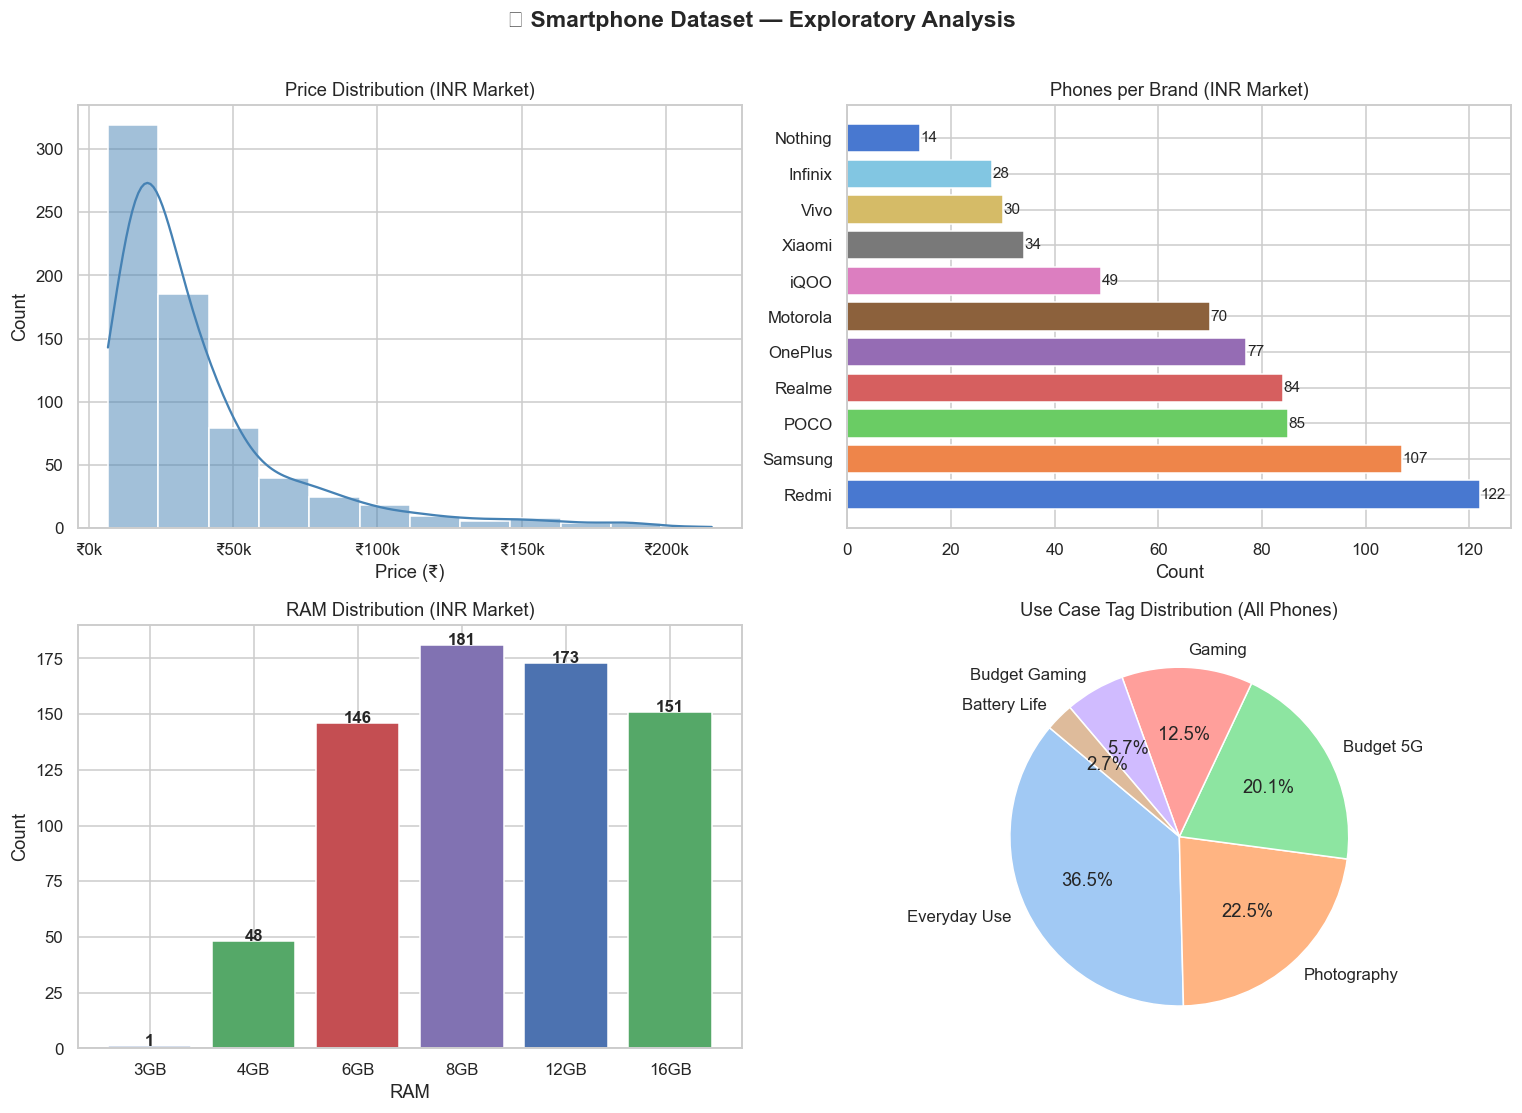

✅ Figure saved as eda_overview.png


In [56]:
# ─── Figure 1: Price Distribution & Brand Count ────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('📱 Smartphone Dataset — Exploratory Analysis', fontsize=15, fontweight='bold', y=1.01)

# 1. Price distribution INR
sns.histplot(df_inr['price'], bins=12, kde=True, ax=axes[0,0],
             color='steelblue', edgecolor='white')
axes[0,0].set_title('Price Distribution (INR Market)')
axes[0,0].set_xlabel('Price (₹)')
axes[0,0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₹{int(x/1000)}k'))

# 2. Brand count INR
brand_counts = df_inr['brand'].value_counts()
axes[0,1].barh(brand_counts.index, brand_counts.values,
               color=sns.color_palette('muted', len(brand_counts)))
axes[0,1].set_title('Phones per Brand (INR Market)')
axes[0,1].set_xlabel('Count')
for i, v in enumerate(brand_counts.values):
    axes[0,1].text(v+0.1, i, str(v), va='center', fontsize=10)

# RAM distribution
ram_counts = df_inr['ram_gb'].value_counts().sort_index()
bars = axes[1,0].bar([str(r)+'GB' for r in ram_counts.index], ram_counts.values,
                      color=['#4c72b0','#55a868','#c44e52','#8172b2'])
axes[1,0].set_title('RAM Distribution (INR Market)')
axes[1,0].set_xlabel('RAM')
axes[1,0].set_ylabel('Count')
for bar in bars:
    axes[1,0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.1,
                   str(int(bar.get_height())), ha='center', fontsize=11, fontweight='bold')

# 4. Use case distribution
uc_counts = df['use_case_tag'].value_counts()
axes[1,1].pie(uc_counts.values, labels=uc_counts.index, autopct='%1.1f%%',
              colors=sns.color_palette('pastel', len(uc_counts)), startangle=140)
axes[1,1].set_title('Use Case Tag Distribution (All Phones)')

plt.tight_layout()
plt.savefig('eda_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Figure saved as eda_overview.png')

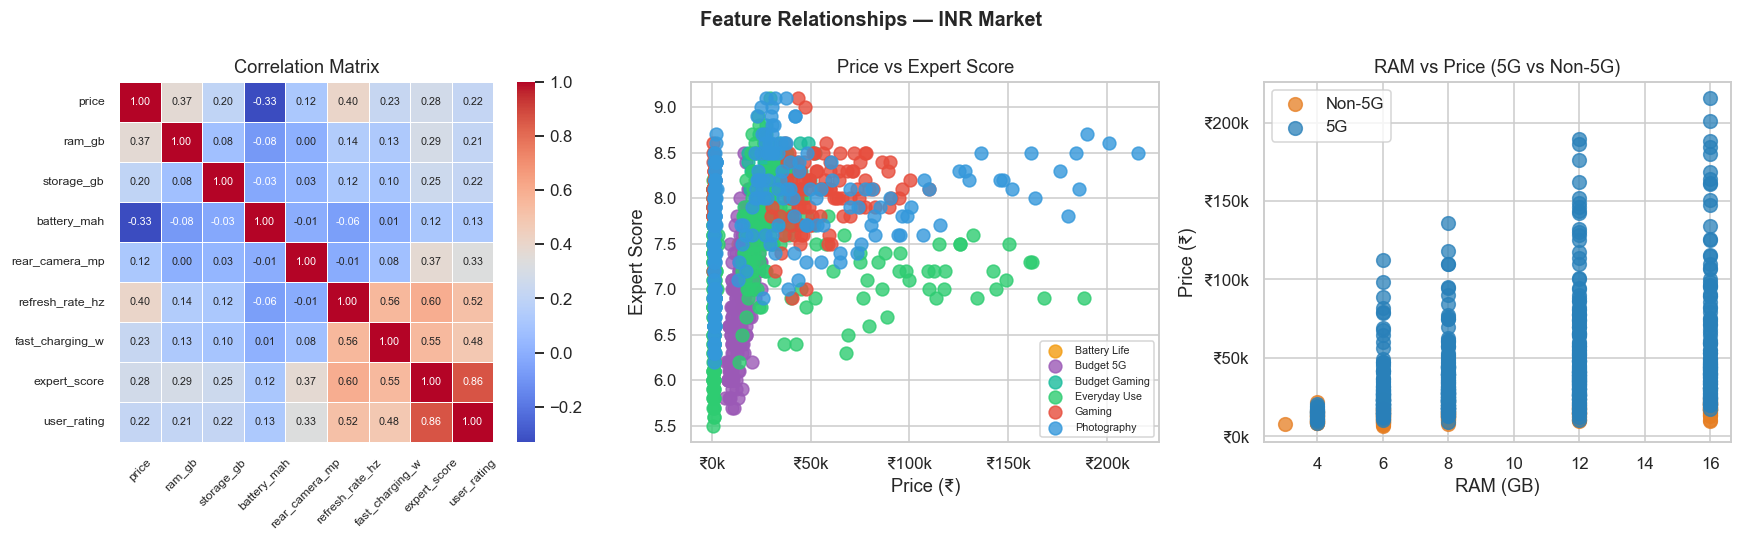

✅ Figure saved as eda_relationships.png


In [57]:
# Figure 2: Feature Correlation & Scatter plots 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Feature Relationships — INR Market', fontsize=13, fontweight='bold')

# Correlation heatmap
num_cols = ['price','ram_gb','storage_gb','battery_mah','rear_camera_mp',
            'refresh_rate_hz','fast_charging_w','expert_score','user_rating']
corr = df_inr[num_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[0], linewidths=0.5, annot_kws={'size':7})
axes[0].set_title('Correlation Matrix')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=8)

# Price vs Expert Score
colors = {'Gaming':'#e74c3c','Photography':'#3498db','Everyday Use':'#2ecc71',
          'Battery Life':'#f39c12','Budget 5G':'#9b59b6','Budget Gaming':'#1abc9c'}
for uc, grp in df.groupby('use_case_tag'):
    axes[1].scatter(grp['price'], grp['expert_score'],
                    label=uc, color=colors.get(uc,'gray'), alpha=0.8, s=70)
axes[1].set_title('Price vs Expert Score')
axes[1].set_xlabel('Price (₹)')
axes[1].set_ylabel('Expert Score')
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₹{int(x/1000)}k'))
axes[1].legend(fontsize=7)

# RAM vs Price by 5G
for has5g, grp in df_inr.groupby('has_5g'):
    axes[2].scatter(grp['ram_gb'], grp['price'],
                    label='5G' if has5g else 'Non-5G',
                    alpha=0.75, s=80,
                    color='#2980b9' if has5g else '#e67e22')
axes[2].set_title('RAM vs Price (5G vs Non-5G)')
axes[2].set_xlabel('RAM (GB)')
axes[2].set_ylabel('Price (₹)')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'₹{int(x/1000)}k'))
axes[2].legend()

plt.tight_layout()
plt.savefig('eda_relationships.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Figure saved as eda_relationships.png')

## ✅ Cell 5 — Knowledge Base: Rules & Processor Tier Rankings

In [58]:
# ─────────────────────────────────────────────────────────────────────────────
#  KNOWLEDGE BASE
#  All domain rules, processor tiers, and use-case weights live here.
#  This is the "intelligence" layer of the Knowledge-Based RS.
# ─────────────────────────────────────────────────────────────────────────────

# ── Processor performance tier (0.0 to 1.0 scale) 
# PROCESSOR_TIER = {
#     # Flagship
#     'A17 Pro'             : 1.00, 'Snapdragon 8 Gen 3'   : 1.00, #Processor
#     'A16 Bionic'          : 0.96, 'Snapdragon 8 Gen 2'   : 0.94,
#     'A15 Bionic'          : 0.92, 'Snapdragon 8+ Gen 1'  : 0.90,
#     'Snapdragon 8 Gen 1'  : 0.87, 'Snapdragon 8s Gen 3'  : 0.88,
#     'Dimensity 9000'      : 0.90, 'Google Tensor G3'     : 0.85,
#     'Google Tensor G2'    : 0.80,
#     # Upper-mid
#     'Snapdragon 7+ Gen 2' : 0.83, 'Snapdragon 7s Gen 3'  : 0.80,
#     'Snapdragon 7 Gen 3'  : 0.78, 'Snapdragon 7s Gen 2'  : 0.76,
#     'Dimensity 8200 Ultra': 0.85, 'Dimensity 8020'       : 0.82,
#     'Dimensity 7350 Pro'  : 0.76, 'Dimensity 7200 Ultra' : 0.75,
#     'Dimensity 7200 Pro'  : 0.73, 'Exynos 1480'          : 0.80,
#     'Exynos 1380'         : 0.70,
#     # Mid-range
#     'Snapdragon 6 Gen 1'  : 0.65, 'Snapdragon 695'       : 0.60,
#     'Snapdragon 4 Gen 2'  : 0.55, 'Exynos 1280'          : 0.65,
#     'Exynos 1330'         : 0.62, 'Dimensity 7050'       : 0.68,
#     'Dimensity 7020'      : 0.65, 'Dimensity 6100+'      : 0.55,
#     'Dimensity 6080'      : 0.52, 'Dimensity 6020'       : 0.50,
#     'Dimensity 1080'      : 0.75,
#     # Budget
#     'Snapdragon 685'      : 0.48, 'Snapdragon 680'       : 0.45,
#     'Helio G99 Ultimate'  : 0.62, 'Helio G99'            : 0.58,
#     'Helio G91 Ultra'     : 0.45, 'Helio G88'            : 0.40,
#     'Helio G85'           : 0.38,
# }

PROCESSOR_TIER = {
    # 🔥 Flagship
    'A18 Pro'             : 1.00,
    'A17 Pro'             : 1.00,
    'Snapdragon 8 Gen 3'  : 1.00,
    'A18'                 : 0.98,
    'Dimensity 9300'      : 0.98,
    'A16 Bionic'          : 0.96,
    'Dimensity 9200+'     : 0.96,
    'Snapdragon 8 Gen 2'  : 0.94,
    'A15 Bionic'          : 0.92,
    'Dimensity 8300 Ultra': 0.92,
    'Snapdragon 8+ Gen 1' : 0.90,
    'Dimensity 9000'      : 0.90,
    'Snapdragon 8s Gen 3' : 0.88,
    'Google Tensor G4'    : 0.88,
    'Snapdragon 8 Gen 1'  : 0.87,
    'Google Tensor G3'    : 0.85,
    'Snapdragon 888'      : 0.85,
    'Google Tensor G2'    : 0.80,

    # ⚡ Upper-Mid
    'Snapdragon 7+ Gen 3' : 0.86,
    'Snapdragon 7+ Gen 2' : 0.83,
    'Dimensity 8200 Ultra': 0.85,
    'Dimensity 8020'      : 0.82,
    'Snapdragon 7s Gen 3' : 0.80,
    'Exynos 1480'         : 0.80,
    'Snapdragon 7 Gen 3'  : 0.78,
    'Snapdragon 778G'     : 0.76,
    'Dimensity 7350 Pro'  : 0.76,
    'Snapdragon 7s Gen 2' : 0.76,
    'Dimensity 7200 Ultra': 0.75,
    'Dimensity 1080'      : 0.75,
    'Snapdragon 782G'     : 0.74,
    'Dimensity 7200 Pro'  : 0.73,
    'Exynos 1380'         : 0.70,

    # 📊 Mid-range
    'Dimensity 930'       : 0.70,
    'Dimensity 7050'      : 0.68,
    'Dimensity 7025 Ultra': 0.68,
    'Dimensity 7025'      : 0.66,
    'Snapdragon 6 Gen 1'  : 0.65,
    'Dimensity 7020'      : 0.65,
    'Exynos 1280'         : 0.65,
    'Snapdragon 732G'     : 0.65,
    'Exynos 1330'         : 0.62,
    'Helio G99 Ultimate'  : 0.62,
    'Snapdragon 695'      : 0.60,
    'Snapdragon 678'      : 0.60,
    'Helio G99'           : 0.58,
    'Snapdragon 4 Gen 2'  : 0.55,
    'Dimensity 6100+'     : 0.55,

    # 💰 Budget
    'Dimensity 6080'      : 0.52,
    'Dimensity 6020'      : 0.50,
    'Snapdragon 685'      : 0.48,
    'Helio G91 Ultra'     : 0.45,
    'Snapdragon 680'      : 0.45,
    'Helio G88'           : 0.40,
    'Helio G85'           : 0.38,
    'Helio G36'           : 0.35,
}
# ── Use-case attribute weight tables ────────────────────────────────────────
# Each use-case defines how important each phone attribute is (weights sum ~ 1)
# USE_CASE_WEIGHTS = {
#     'Gaming': {
#         'processor' : 0.30, 'ram'       : 0.25,
#         'refresh'   : 0.20, 'battery'   : 0.10,
#         'storage'   : 0.10, 'camera'    : 0.05,
#     },
#     'Photography': {
#         'camera'    : 0.35, 'display'   : 0.20,
#         'storage'   : 0.15, 'ram'       : 0.15,
#         'battery'   : 0.15,
#     },
#     'Everyday Use': {
#         'battery'   : 0.25, 'ram'       : 0.20,
#         'storage'   : 0.20, 'camera'    : 0.15,
#         'refresh'   : 0.10, 'display'   : 0.10,
#     },
#     'Battery Life': {
#         'battery'   : 0.40, 'processor' : 0.20,
#         'ram'       : 0.20, 'display'   : 0.10,
#         'camera'    : 0.10,
#     },
#     'Business/Productivity': {
#         'ram'       : 0.25, 'storage'   : 0.20,
#         'display'   : 0.20, 'camera'    : 0.15,
#         'battery'   : 0.20,
#     },
# }
USE_CASE_WEIGHTS = {

    # 🎮 Gaming
    'Gaming': {
        'processor' : 0.30,
        'ram'       : 0.25,
        'refresh'   : 0.20,
        'battery'   : 0.10,
        'storage'   : 0.10,
        'camera'    : 0.05,
    },

    # 📸 Camera
    'Camera': {
        'camera'    : 0.40,
        'display'   : 0.20,
        'processor' : 0.15,
        'storage'   : 0.10,
        'ram'       : 0.10,
        'battery'   : 0.05,
    },

    # 🔋 Battery
    'Battery': {
        'battery'   : 0.40,
        'processor' : 0.20,
        'ram'       : 0.15,
        'display'   : 0.10,
        'refresh'   : 0.10,
        'camera'    : 0.05,
    },

    # ⚡ Performance
    'Performance': {
        'processor' : 0.35,
        'ram'       : 0.25,
        'storage'   : 0.15,
        'refresh'   : 0.10,
        'battery'   : 0.10,
        'camera'    : 0.05,
    },

    # ⚖️ All-Rounder
    'All-Rounder': {
        'processor' : 0.20,
        'camera'    : 0.20,
        'battery'   : 0.20,
        'ram'       : 0.15,
        'storage'   : 0.10,
        'display'   : 0.10,
        'refresh'   : 0.05,
    },

    # 💰 Budget
    'Budget': {
        'price'     : 0.35,
        'battery'   : 0.20,
        'processor' : 0.15,
        'ram'       : 0.10,
        'storage'   : 0.10,
        'camera'    : 0.10,
    }
}
# ── Knowledge Rules (IF-THEN rules applied during scoring) ──────────────────
# These mimic expert domain knowledge
# These are if then rules
KNOWLEDGE_RULES = [
    {'name': '5G Bonus',           'condition': lambda p,_: p['has_5g'],               'bonus': 0.05}, # if phone has 5g then add score
    {'name': 'AMOLED Bonus',       'condition': lambda p,_: p['is_amoled'],             'bonus': 0.04},
    {'name': 'Fast Charge Bonus',  'condition': lambda p,_: p['fast_charging_w'] >= 67, 'bonus': 0.04},
    {'name': 'NFC Bonus',          'condition': lambda p,_: p['has_nfc'],               'bonus': 0.02},
    {'name': 'High Camera Pref',   'condition': lambda p,pref: pref.get('camera_priority')=='High' and p['rear_camera_mp']>=64, 'bonus': 0.05},
    {'name': 'High Battery Pref',  'condition': lambda p,pref: pref.get('battery_priority')=='High' and p['battery_mah']>=5000, 'bonus': 0.04},
    {'name': 'Brand Match',        'condition': lambda p,pref: pref.get('brand','Any')!='Any' and p['brand']==pref.get('brand'), 'bonus': 0.04},
    {'name': 'Proc Brand Match',   'condition': lambda p,pref: pref.get('proc_brand','Any')!='Any' and p['processor_brand']==pref.get('proc_brand'), 'bonus': 0.03},
    {'name': 'New Device Bonus',   'condition': lambda p,_: p['release_year'] >= 2024,  'bonus': 0.02},
]

print('✅ Knowledge Base loaded!')
print(f'   Processors ranked  : {len(PROCESSOR_TIER)}')
print(f'   Use-case profiles  : {len(USE_CASE_WEIGHTS)}')
print(f'   Knowledge rules    : {len(KNOWLEDGE_RULES)}')
print()
print('Processor Tier Sample (Top 5 vs Bottom 5):')
sorted_procs = sorted(PROCESSOR_TIER.items(), key=lambda x: -x[1])
print(tabulate(sorted_procs[:5]+[('...','...')]+sorted_procs[-5:],
               headers=['Processor','Tier Score'], tablefmt='rounded_outline', floatfmt='.2f'))

✅ Knowledge Base loaded!
   Processors ranked  : 56
   Use-case profiles  : 6
   Knowledge rules    : 9

Processor Tier Sample (Top 5 vs Bottom 5):
╭────────────────────┬──────────────╮
│ Processor          │ Tier Score   │
├────────────────────┼──────────────┤
│ A18 Pro            │ 1.0          │
│ A17 Pro            │ 1.0          │
│ Snapdragon 8 Gen 3 │ 1.0          │
│ A18                │ 0.98         │
│ Dimensity 9300     │ 0.98         │
│ ...                │ ...          │
│ Helio G91 Ultra    │ 0.45         │
│ Snapdragon 680     │ 0.45         │
│ Helio G88          │ 0.4          │
│ Helio G85          │ 0.38         │
│ Helio G36          │ 0.35         │
╰────────────────────┴──────────────╯


## ✅ Cell 6 — Recommendation Engine (Core Logic)

In [59]:
# Example:
# use_case = "Gaming"
# preferences = {
#     'brand': 'Samsung',
#     'camera_priority': 'High'
# }
# Step 1 = Use weights
# For Gaming Ram,Processor,Refersh has High Score
# Gaming → processor 30%, RAM 25%
# Step 2= Add processor score
# Snapdragon 8 Gen 2 → 0.94
# Step 3= Apply rules
# if 5G then +0.05
# if AMOLED then +0.04
# if Brand match then +0.04
# finalscore= baseSCore+Bounes


In [65]:
# ─────────────────────────────────────────────────────────────────────────────
#  RECOMMENDATION ENGINE
#  All 12 features implemented inside this class.
# ─────────────────────────────────────────────────────────────────────────────

class SmartphoneRecommender: #takes dataset -> processes the data -> gives recommendations
    """
    Knowledge-Based Smartphone Recommender System.

    Workflow:
      1. Filter  → Hard constraints  (budget, RAM, storage, OS, 5G)
      2. Score   → Weighted soft attributes per use-case profile
      3. Boost   → Knowledge rules (expert IF-THEN rules)
      4. Rank    → Sort by composite score
      5. Explain → Generate human-readable reasoning
      6. Fallback→ Relax constraints if no match found
    """

    def __init__(self, dataframe):
        self.df = dataframe.copy()

    # Attribute normalizer (convert it into a same 0 to 1 scale) 
    def _normalize(self, phone):
        return {
            'processor' : PROCESSOR_TIER.get(phone['processor'], 0.40), #0.40 is default value
            'ram'       : min(phone['ram_gb'] / 16, 1.0), # Ram is 6 GB -> 6 / 12 = 0.5 1 is the max value.
            'storage'   : min(phone['storage_gb'] / 1000, 1.0),
            'camera'    : min(phone['rear_camera_mp'] / 200, 1.0)
                          + (0.15 if phone['front_camera_mp'] >= 32 else
                             0.08 if phone['front_camera_mp'] >= 16 else 0),
            'battery'   : min(max(phone['battery_mah'] - 3000, 0) / 5000, 1.0),
            'refresh'   : min(phone['refresh_rate_hz'] / 165, 1.0),
            'display'   : 1.0 if phone['is_amoled'] else 0.5,
        }

    # Feature 3 & 4: Weighted soft-score per use-case
    # calc based score using Weights.
    
    def _soft_score(self, phone, use_case):
        norm   = self._normalize(phone) #call the normalize fun.
        weights = USE_CASE_WEIGHTS.get(use_case, USE_CASE_WEIGHTS['All-Rounder']) #(Value,defalut value.)
        score  = sum(norm.get(attr, 0) * w for attr, w in weights.items())
        return round(min(score, 1.0), 4)

    # ── Feature 9–11: Apply Rule-based and calc. bonus score 
    def _rule_bonus(self, phone, prefs):
        bonus = 0.0
        fired = [] # which rules are applied.
        for rule in KNOWLEDGE_RULES:
            try:
                if rule['condition'](phone, prefs):
                    bonus += rule['bonus']
                    fired.append(rule['name'])
            except Exception:
                pass
        return round(min(bonus, 0.25), 4), fired  # cap bonus at 25%

    # ── Feature 6: Human-readable explanation 
    # Why this phone is recommend.
    def _explain(self, phone, prefs, match_pct):
        sym  = '₹' if prefs['currency'] == 'INR' else '$'
        bud  = prefs.get('budget_inr') if prefs['currency']=='INR' else prefs.get('budget_usd')
        good, warn = [], []

        # Budget
        if phone['price'] <= bud:
            good.append(f"{sym}{phone['price']:,} — within your {sym}{bud:,} budget")
        else:
            warn.append(f"{sym}{phone['price']:,} exceeds budget ({sym}{bud:,})")

        # RAM
        if phone['ram_gb'] >= prefs['min_ram']:
            good.append(f"{phone['ram_gb']}GB RAM — meets your {prefs['min_ram']}GB requirement")
        else:
            warn.append(f"Only {phone['ram_gb']}GB RAM (you need {prefs['min_ram']}GB)")

        # Storage
        if phone['storage_gb'] >= prefs['min_storage']:
            good.append(f"{phone['storage_gb']}GB storage — satisfies {prefs['min_storage']}GB requirement")
        else:
            warn.append(f"Only {phone['storage_gb']}GB storage (you need {prefs['min_storage']}GB)")

        # 5G
        if prefs.get('require_5g') and phone['has_5g']:
            good.append('5G ready — as required')
        elif prefs.get('require_5g') and not phone['has_5g']:
            warn.append('No 5G connectivity')
        elif phone['has_5g']:
            good.append('5G included — future-proofed')

        # Camera
        if phone['rear_camera_mp'] >= 100:
            good.append(f"{phone['rear_camera_mp']}MP main camera — excellent photography")
        elif phone['rear_camera_mp'] >= 50:
            good.append(f"{phone['rear_camera_mp']}MP rear camera — solid shots")

        # Battery
        if phone['battery_mah'] >= 5500:
            good.append(f"{phone['battery_mah']:,}mAh — exceptional battery life")
        elif phone['battery_mah'] >= 5000:
            good.append(f"{phone['battery_mah']:,}mAh — all-day endurance")

        # Display
        if phone['refresh_rate_hz'] >= 120:
            good.append(f"{phone['refresh_rate_hz']}Hz {phone['display_type']} — super smooth display")

        # Fast charging
        if phone['fast_charging_w'] >= 67:
            good.append(f"{phone['fast_charging_w']}W fast charging — top up in minutes")

        return good[:5], warn[:3]

    # ── Feature 7: Trade-off summary 
    def _tradeoffs(self, phone, prefs):
        sym = '₹' if prefs['currency']=='INR' else '$'
        bud = prefs.get('budget_inr') if prefs['currency']=='INR' else prefs.get('budget_usd')
        tof = []
        if phone['price'] > bud:
            over = phone['price'] - bud
            tof.append(f"Price is {sym}{over:,} over budget")
        if phone['ram_gb'] < prefs['min_ram']:
            tof.append(f"RAM: {phone['ram_gb']}GB < required {prefs['min_ram']}GB")
        if phone['storage_gb'] < prefs['min_storage']:
            tof.append(f"Storage: {phone['storage_gb']}GB < required {prefs['min_storage']}GB")
        if prefs.get('require_5g') and not phone['has_5g']:
            tof.append('Missing required 5G')
        if phone['battery_mah'] < 4000:
            tof.append(f"Battery only {phone['battery_mah']:,}mAh — may need top-ups")
        return tof

    # ── Feature 2 & 12: Filter with optional relaxation ──────────────────────
    def _filter(self, prefs, relax=False):
        pool = self.df[self.df['currency'] == prefs['currency']].copy()
        bud  = prefs.get('budget_inr') if prefs['currency']=='INR' else prefs.get('budget_usd')

        if not relax:
            mask = (
                (pool['price']      <= bud) &
                (pool['ram_gb']     >= prefs['min_ram']) &
                (pool['storage_gb'] >= prefs['min_storage'])
            )
            if prefs.get('os', 'Any') != 'Any':
                mask &= (pool['os'] == prefs['os'])
            if prefs.get('require_5g'):
                mask &= pool['has_5g']
            return pool[mask]
        else:
            # Relaxed: +20% budget, -2GB RAM floor, keep OS
            mask = (
                (pool['price']      <= bud * 1.20) &
                (pool['ram_gb']     >= max(prefs['min_ram'] - 2, 2)) &
                (pool['storage_gb'] >= max(prefs['min_storage'] // 2, 64))
            )
            if prefs.get('os','Any') != 'Any':
                mask &= (pool['os'] == prefs['os'])
            return pool[mask]

    # ── MAIN RECOMMEND METHOd
    def recommend(self, prefs, top_n=5):
        """
        Parameters
        ----------
        prefs : dict — User preferences:
            currency         : 'INR' or 'USD'
            budget_inr       : int  (e.g. 20000)
            budget_usd       : int  (e.g. 400)
            min_ram          : int  (e.g. 8)
            min_storage      : int  (e.g. 128)
            os               : 'Android' | 'iOS' | 'Any'
            require_5g       : bool
            use_case         : str  (from USE_CASE_WEIGHTS)
            camera_priority  : 'Low' | 'Medium' | 'High'
            battery_priority : 'Low' | 'Medium' | 'High'
            brand            : str  (e.g. 'Samsung') or 'Any'
            proc_brand       : str  (e.g. 'Qualcomm') or 'Any'
        top_n : int — Number of recommendations to return

        Returns
        -------
        dict with keys: results (list), relaxed (bool), total_filtered (int)
        """
        # Feature 2: Hard filtering
        filtered = self._filter(prefs, relax=False)
        relaxed  = False

        # Feature 12: Relaxed fallback
        if len(filtered) == 0:
            filtered = self._filter(prefs, relax=True)
            relaxed  = True

        if len(filtered) == 0:
            return {'results': [], 'relaxed': relaxed, 'total_filtered': 0}

        results = []
        for _, phone in filtered.iterrows():
            p = phone.to_dict()

            # Feature 3 & 4: Soft scoring
            soft = self._soft_score(p, prefs.get('use_case','Everyday Use'))

            # Feature 5 & 9–11: Rule-based bonus
            bonus, fired_rules = self._rule_bonus(p, prefs)

            # Composite score
            composite = round(min(soft + bonus, 1.0), 4)
            match_pct = round(composite * 100, 1)

            # Feature 6: Explanations
            pros, cons = self._explain(p, prefs, match_pct)

            # Feature 7: Trade-offs
            tofs = self._tradeoffs(p, prefs)

            results.append({
                'phone'       : p,
                'soft_score'  : soft,
                'rule_bonus'  : bonus,
                'composite'   : composite,
                'match_pct'   : match_pct,
                'pros'        : pros,
                'cons'        : cons,
                'tradeoffs'   : tofs,
                'fired_rules' : fired_rules,
            })

        # Sort by composite score (desc), then by expert_score as tiebreaker
        results.sort(key=lambda x: (x['composite'], x['phone']['expert_score']), reverse=True)

        return {
            'results'       : results[:top_n],
            'relaxed'       : relaxed,
            'total_filtered': len(filtered),
        }


# ── Instantiate the recommender ───────────────────────────────────────────────
RS = SmartphoneRecommender(df)
print('✅ SmartphoneRecommender engine initialised!')
print(f'   Total phones loaded : {len(RS.df)}')

✅ SmartphoneRecommender engine initialised!
   Total phones loaded : 1000


## ✅ Cell 7 — Pretty Print Helper (Formatted Output)

In [67]:
RANK_ICONS = ['🥇','🥈','🥉','4️⃣','5️⃣']

def match_badge(pct):
    if pct >= 85: return f'\033[92m{pct:.1f}% MATCH ✅\033[0m'
    if pct >= 70: return f'\033[94m{pct:.1f}% MATCH 🔵\033[0m'
    if pct >= 55: return f'\033[93m{pct:.1f}% MATCH 🟡\033[0m'
    return                f'\033[91m{pct:.1f}% MATCH 🔴\033[0m'

def print_results(output, prefs, show_rules=False):
    sym  = '₹' if prefs['currency']=='INR' else '$'
    bud  = prefs.get('budget_inr') if prefs['currency']=='INR' else prefs.get('budget_usd')
    line = '─' * 68

    print(f'\n{"═"*68}')
    print(f'  📱 SMARTPHONE RECOMMENDATION RESULTS')
    print(f'  Market: {prefs["currency"]}  |  Budget: {sym}{bud:,}  |  Use Case: {prefs.get("use_case","Everyday Use")}')
    print(f'  RAM ≥ {prefs["min_ram"]}GB  |  Storage ≥ {prefs["min_storage"]}GB  |  5G: {"Required" if prefs.get("require_5g") else "Optional"}')
    print(f'{"═"*68}')

    if output['relaxed']:
        print('  ⚠️  NOTE: No exact matches found. Showing closest alternatives')
        print('      with relaxed constraints (+20% budget, relaxed RAM/Storage).')
        print(f'  {line}')

    if not output['results']:
        print('  ❌ No phones matched even with relaxed constraints.')
        print('     Suggestions: Increase budget, reduce RAM/Storage requirements.')
        return

    print(f'  Found {output["total_filtered"]} phones after filtering → Top {len(output["results"])} shown\n')

    for i, rec in enumerate(output['results']):
        p    = rec['phone']
        icon = RANK_ICONS[i] if i < len(RANK_ICONS) else f'#{i+1}'

        print(f'  {icon}  {p["brand"]} {p["model"]}   {match_badge(rec["match_pct"])}')
        print(f'  {line}')

        # Price row
        print(f'  💰 Price         : {sym}{p["price"]:,}')

        # Spec grid
        specs = [
            ('RAM',      f'{p["ram_gb"]}GB'),
            ('Storage',  f'{p["storage_gb"]}GB'),
            ('Battery',  f'{p["battery_mah"]:,}mAh'),
            ('Camera',   f'{p["rear_camera_mp"]}MP + {p["front_camera_mp"]}MP selfie'),
            ('Display',  f'{p["refresh_rate_hz"]}Hz {p["display_type"]}'),
            ('Proc',     f'{p["processor"]} ({p["processor_brand"]})'),
            ('5G/NFC',   f'{"✅" if p["has_5g"] else "❌"} / {"✅" if p["has_nfc"] else "❌"}'),
            ('Charging', f'{p["fast_charging_w"]}W  |  Weight: {p["weight_g"]}g'),
        ]
        for label, val in specs:
            print(f'     {label:<10}: {val}')

        # Score breakdown
        print(f'  📊 Score Breakdown:')
        print(f'     Soft score   : {rec["soft_score"]*100:.1f}%')
        print(f'     Rule bonus   : +{rec["rule_bonus"]*100:.1f}%')
        print(f'     Composite    : {rec["composite"]*100:.1f}%  (Expert: {p["expert_score"]}/10  |  Users: {p["user_rating"]}/5)')

        # Pros
        if rec['pros']:
            print(f'  ✅ Why recommended:')
            for r in rec['pros']:
                print(f'      • {r}')

        # Trade-offs
        if rec['tradeoffs']:
            print(f'  ⚠️  Trade-offs:')
            for t in rec['tradeoffs']:
                print(f'      • {t}')

        # Fired rules
        if show_rules and rec['fired_rules']:
            print(f'  🔧 Rules fired: {" | ".join(rec["fired_rules"])}')

        print()

    print(f'  {"═"*68}')
    print(f'  💡 Tip: Phone scored on {prefs.get("use_case","Everyday Use")} profile.')
    print(f'  📌 All scores normalised 0–100%. Higher = better fit to your needs.')
    print(f'  {"═"*68}\n')


print('✅ Display helpers ready!')

✅ Display helpers ready!


## ✅ Cell 8 — Run Test Cases (5 Realistic User Scenarios)

In [68]:
# ─── Test Case 1: Classic student query (INR, ₹20k budget, 8GB RAM) ───────────
prefs_1 = {
    'currency'        : 'INR',
    'budget_inr'      : 20000,
    'min_ram'         : 8,
    'min_storage'     : 128,
    'os'              : 'Any',
    'require_5g'      : False,
    'use_case'        : 'All-Rounder',
    'camera_priority' : 'Medium',
    'battery_priority': 'Medium',
    'brand'           : 'Any',
    'proc_brand'      : 'Any',
}

out_1 = RS.recommend(prefs_1, top_n=5)
print_results(out_1, prefs_1, show_rules=True)


════════════════════════════════════════════════════════════════════
  📱 SMARTPHONE RECOMMENDATION RESULTS
  Market: INR  |  Budget: ₹20,000  |  Use Case: All-Rounder
  RAM ≥ 8GB  |  Storage ≥ 128GB  |  5G: Optional
════════════════════════════════════════════════════════════════════
  Found 81 phones after filtering → Top 5 shown

  🥇  Redmi Note 13 5G (16GB/128GB)   72.3% MATCH 🔵
  ────────────────────────────────────────────────────────────────────
  💰 Price         : ₹19,972
     RAM       : 16GB
     Storage   : 128GB
     Battery   : 5,000mAh
     Camera    : 108MP + 16.0MP selfie
     Display   : 120Hz AMOLED
     Proc      : Snapdragon 4 Gen 2 (Qualcomm)
     5G/NFC    : ✅ / ❌
     Charging  : 33W  |  Weight: 174g
  📊 Score Breakdown:
     Soft score   : 61.3%
     Rule bonus   : +11.0%
     Composite    : 72.3%  (Expert: 7.8/10  |  Users: 3.6/5)
  ✅ Why recommended:
      • ₹19,972 — within your ₹20,000 budget
      • 16GB RAM — meets your 8GB requirement
      • 128GB storag

In [69]:
# ─── Test Case 2: Gamer on a budget (INR, 5G, Gaming, Qualcomm) ───────────────
prefs_2 = {
    'currency'        : 'INR',
    'budget_inr'      : 18000,
    'min_ram'         : 8,
    'min_storage'     : 128,
    'os'              : 'Android',
    'require_5g'      : True,
    'use_case'        : 'Gaming',
    'camera_priority' : 'Low',
    'battery_priority': 'Medium',
    'brand'           : 'Any',
    'proc_brand'      : 'Qualcomm',
}

out_2 = RS.recommend(prefs_2, top_n=5)
print_results(out_2, prefs_2)


════════════════════════════════════════════════════════════════════
  📱 SMARTPHONE RECOMMENDATION RESULTS
  Market: INR  |  Budget: ₹18,000  |  Use Case: Gaming
  RAM ≥ 8GB  |  Storage ≥ 128GB  |  5G: Required
════════════════════════════════════════════════════════════════════
  Found 19 phones after filtering → Top 5 shown

  🥇  Redmi Note 13 5G (12GB/128GB)   72.2% MATCH 🔵
  ────────────────────────────────────────────────────────────────────
  💰 Price         : ₹17,354
     RAM       : 12GB
     Storage   : 128GB
     Battery   : 5,000mAh
     Camera    : 108MP + 16.0MP selfie
     Display   : 120Hz AMOLED
     Proc      : Snapdragon 4 Gen 2 (Qualcomm)
     5G/NFC    : ✅ / ❌
     Charging  : 33W  |  Weight: 174g
  📊 Score Breakdown:
     Soft score   : 58.2%
     Rule bonus   : +14.0%
     Composite    : 72.2%  (Expert: 8.4/10  |  Users: 4.3/5)
  ✅ Why recommended:
      • ₹17,354 — within your ₹18,000 budget
      • 12GB RAM — meets your 8GB requirement
      • 128GB storage — s

In [70]:
# ─── Test Case 3: Photography enthusiast (INR, camera priority High) ──────────
prefs_3 = {
    'currency'        : 'INR',
    'budget_inr'      : 28000,
    'min_ram'         : 8,
    'min_storage'     : 128,
    'os'              : 'Android',
    'require_5g'      : True,
    'use_case'        : 'Photography',
    'camera_priority' : 'High',
    'battery_priority': 'Low',
    'brand'           : 'Any',
    'proc_brand'      : 'Any',
}

out_3 = RS.recommend(prefs_3, top_n=5)
print_results(out_3, prefs_3)


════════════════════════════════════════════════════════════════════
  📱 SMARTPHONE RECOMMENDATION RESULTS
  Market: INR  |  Budget: ₹28,000  |  Use Case: Photography
  RAM ≥ 8GB  |  Storage ≥ 128GB  |  5G: Required
════════════════════════════════════════════════════════════════════
  Found 104 phones after filtering → Top 5 shown

  🥇  Redmi Note 13 Pro   90.9% MATCH ✅
  ────────────────────────────────────────────────────────────────────
  💰 Price         : ₹22,999
     RAM       : 8GB
     Storage   : 256GB
     Battery   : 5,100mAh
     Camera    : 200MP + 16.0MP selfie
     Display   : 120Hz AMOLED
     Proc      : Snapdragon 7s Gen 2 (Qualcomm)
     5G/NFC    : ✅ / ✅
     Charging  : 67W  |  Weight: 187g
  📊 Score Breakdown:
     Soft score   : 68.9%
     Rule bonus   : +22.0%
     Composite    : 90.9%  (Expert: 8.9/10  |  Users: 4.6/5)
  ✅ Why recommended:
      • ₹22,999 — within your ₹28,000 budget
      • 8GB RAM — meets your 8GB requirement
      • 256GB storage — satisfie

In [71]:
# ─── Test Case 4: Global market — Apple iOS user (USD) ────────────────────────
prefs_4 = {
    'currency'        : 'USD',
    'budget_usd'      : 900,
    'min_ram'         : 6,
    'min_storage'     : 128,
    'os'              : 'iOS',
    'require_5g'      : True,
    'use_case'        : 'Photography',
    'camera_priority' : 'High',
    'battery_priority': 'Medium',
    'brand'           : 'Apple',
    'proc_brand'      : 'Apple',
}

out_4 = RS.recommend(prefs_4, top_n=3)
print_results(out_4, prefs_4)


════════════════════════════════════════════════════════════════════
  📱 SMARTPHONE RECOMMENDATION RESULTS
  Market: USD  |  Budget: $900  |  Use Case: Photography
  RAM ≥ 6GB  |  Storage ≥ 128GB  |  5G: Required
════════════════════════════════════════════════════════════════════
  Found 15 phones after filtering → Top 3 shown

  🥇  Apple iPhone 16 Plus   73.0% MATCH 🔵
  ────────────────────────────────────────────────────────────────────
  💰 Price         : $899
     RAM       : 8GB
     Storage   : 256GB
     Battery   : 4,674mAh
     Camera    : 48MP + 12.0MP selfie
     Display   : 60Hz OLED
     Proc      : A18 (Apple)
     5G/NFC    : ✅ / ✅
     Charging  : 25W  |  Weight: 203g
  📊 Score Breakdown:
     Soft score   : 53.0%
     Rule bonus   : +20.0%
     Composite    : 73.0%  (Expert: 6.7/10  |  Users: 3.4/5)
  ✅ Why recommended:
      • $899 — within your $900 budget
      • 8GB RAM — meets your 6GB requirement
      • 256GB storage — satisfies 128GB requirement
      • 5G re

In [72]:
# ─── Test Case 5: Impossible constraint → Auto-relax fallback ─────────────────
prefs_5 = {
    'currency'        : 'INR',
    'budget_inr'      : 10000,   # Very tight budget
    'min_ram'         : 12,       # Very high RAM at this budget
    'min_storage'     : 256,
    'os'              : 'Android',
    'require_5g'      : True,
    'use_case'        : 'Gaming',
    'camera_priority' : 'High',
    'battery_priority': 'High',
    'brand'           : 'Any',
    'proc_brand'      : 'Any',
}

out_5 = RS.recommend(prefs_5, top_n=3)
print_results(out_5, prefs_5)


════════════════════════════════════════════════════════════════════
  📱 SMARTPHONE RECOMMENDATION RESULTS
  Market: INR  |  Budget: ₹10,000  |  Use Case: Gaming
  RAM ≥ 12GB  |  Storage ≥ 256GB  |  5G: Required
════════════════════════════════════════════════════════════════════
  ⚠️  NOTE: No exact matches found. Showing closest alternatives
      with relaxed constraints (+20% budget, relaxed RAM/Storage).
  ────────────────────────────────────────────────────────────────────
  Found 3 phones after filtering → Top 3 shown

  🥇  POCO C65 (12GB/128GB)   53.6% MATCH 🔴
  ────────────────────────────────────────────────────────────────────
  💰 Price         : ₹10,808
     RAM       : 12GB
     Storage   : 128GB
     Battery   : 5,000mAh
     Camera    : 50MP + 8.0MP selfie
     Display   : 90Hz IPS
     Proc      : Helio G85 (MediaTek)
     5G/NFC    : ❌ / ❌
     Charging  : 18W  |  Weight: 192g
  📊 Score Breakdown:
     Soft score   : 47.6%
     Rule bonus   : +6.0%
     Composite    :

## ✅ Cell 9 — Score Visualisation (Bar chart of top results)

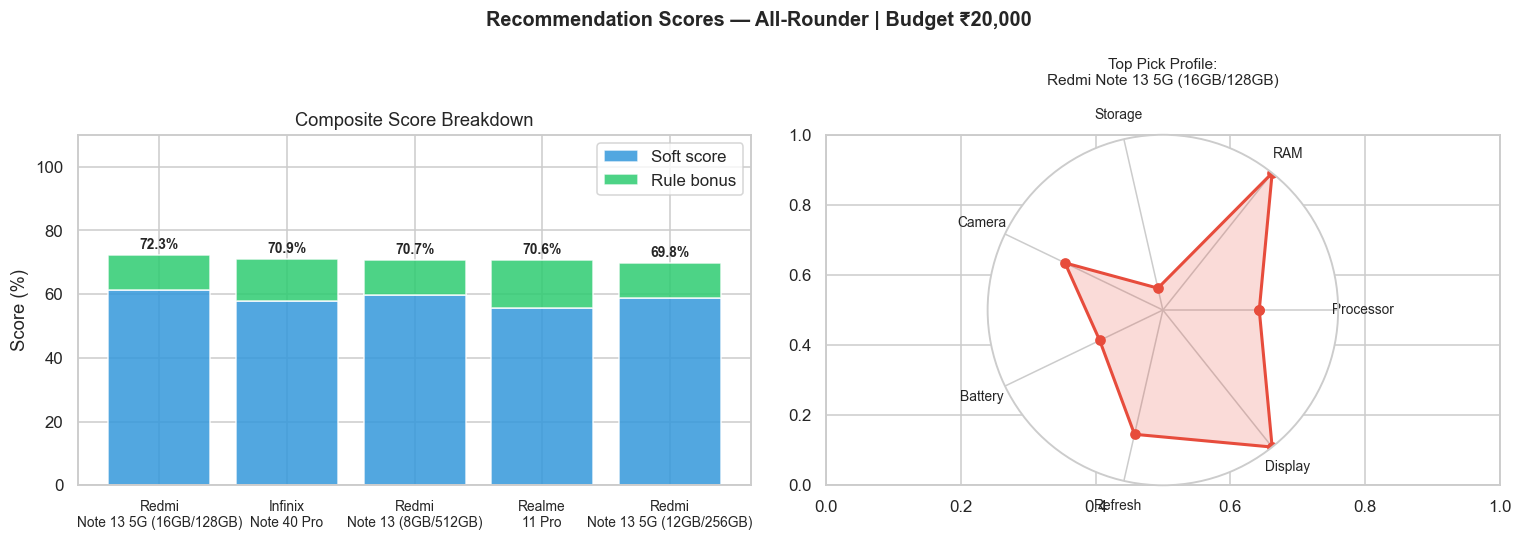

✅ Chart saved as recommendation_scores.png


In [73]:
# ─── Visualise scores for any recommendation output 

def visualise_scores(output, prefs, title_suffix=''):
    if not output['results']:
        print('No results to visualise.')
        return

    results = output['results']
    labels  = [f"{r['phone']['brand']}\n{r['phone']['model']}" for r in results]
    soft    = [r['soft_score']*100 for r in results]
    bonus   = [r['rule_bonus']*100 for r in results]
    sym     = '₹' if prefs['currency']=='INR' else '$'
    bud     = prefs.get('budget_inr') if prefs['currency']=='INR' else prefs.get('budget_usd')

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Recommendation Scores — {prefs["use_case"]} | Budget {sym}{bud:,} {title_suffix}',
                 fontsize=13, fontweight='bold')

    # Stacked bar: soft score + rule bonus
    x     = range(len(labels))
    bars1 = axes[0].bar(x, soft,  color='#3498db', label='Soft score',   alpha=0.85)
    bars2 = axes[0].bar(x, bonus, bottom=soft, color='#2ecc71', label='Rule bonus', alpha=0.85)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, fontsize=9)
    axes[0].set_ylabel('Score (%)')
    axes[0].set_title('Composite Score Breakdown')
    axes[0].legend()
    axes[0].set_ylim(0, 110)
    for i, (s, b) in enumerate(zip(soft, bonus)):
        axes[0].text(i, s+b+1, f'{s+b:.1f}%', ha='center', va='bottom', fontsize=9, fontweight='bold')

    # Radar-style attribute scores for top phone
    top  = results[0]['phone']
    norm = RS._normalize(top)
    cats = ['Processor','RAM','Storage','Camera','Battery','Refresh','Display']
    vals = [norm.get(k.lower(),0)*100 for k in cats]

    N     = len(cats)
    theta = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
    vals  += vals[:1];  theta += theta[:1]

    ax2 = plt.subplot(122, polar=True)
    ax2.plot(theta, vals, 'o-', linewidth=2, color='#e74c3c')
    ax2.fill(theta, vals, alpha=0.20, color='#e74c3c')
    ax2.set_xticks(theta[:-1])
    ax2.set_xticklabels(cats, fontsize=9)
    ax2.set_ylim(0, 100)
    ax2.set_title(f'Top Pick Profile:\n{top["brand"]} {top["model"]}',
                  fontsize=10, pad=15)
    ax2.yaxis.set_visible(False)

    plt.tight_layout()
    plt.savefig('recommendation_scores.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('✅ Chart saved as recommendation_scores.png')


# Visualise test case 1
visualise_scores(out_1, prefs_1)

In [75]:
# ─── Side-by-side spec comparison table 

def compare_specs(output, prefs, n=3):
    if not output['results']:
        print('No results.'); return

    sym  = '₹' if prefs['currency']=='INR' else '$'
    recs = output['results'][:n]
    rows = []
    attrs = [
        ('Price',       lambda p: f"{sym}{p['price']:,}"),
        ('RAM',         lambda p: f"{p['ram_gb']}GB"),
        ('Storage',     lambda p: f"{p['storage_gb']}GB"),
        ('Processor',   lambda p: p['processor']),
        ('Battery',     lambda p: f"{p['battery_mah']:,}mAh"),
        ('Rear Camera', lambda p: f"{p['rear_camera_mp']}MP"),
        ('Front Camera',lambda p: f"{p['front_camera_mp']}MP"),
        ('Display',     lambda p: f"{p['refresh_rate_hz']}Hz {p['display_type']}"),
        ('5G',          lambda p: '✅' if p['has_5g'] else '❌'),
        ('NFC',         lambda p: '✅' if p['has_nfc'] else '❌'),
        ('Fast Charge', lambda p: f"{p['fast_charging_w']}W"),
        ('OS',          lambda p: p['os']),
        ('Match %',     lambda p: None),  # handled below
        ('Expert Score',lambda p: f"{p['expert_score']}/10"),
        ('User Rating', lambda p: f"{p['user_rating']}/5"),
    ]

    headers = ['Attribute'] + [f"{r['phone']['brand']} {r['phone']['model']}" for r in recs]

    for label, fn in attrs:
        row = [label]
        for r in recs:
            if label == 'Match %':
                row.append(f"{r['match_pct']:.1f}%")
            else:
                row.append(fn(r['phone']))
        rows.append(row)

    print(f'\n📊 SPEC COMPARISON — Top {n} Recommendations')
    print(tabulate(rows, headers=headers, tablefmt='rounded_outline'))


compare_specs(out_1, prefs_1, n=3)


📊 SPEC COMPARISON — Top 3 Recommendations
╭──────────────┬─────────────────────────────────┬───────────────────────┬─────────────────────────────╮
│ Attribute    │ Redmi Note 13 5G (16GB/128GB)   │ Infinix Note 40 Pro   │ Redmi Note 13 (8GB/512GB)   │
├──────────────┼─────────────────────────────────┼───────────────────────┼─────────────────────────────┤
│ Price        │ ₹19,972                         │ ₹17,999               │ ₹19,752                     │
│ RAM          │ 16GB                            │ 8GB                   │ 8GB                         │
│ Storage      │ 128GB                           │ 256GB                 │ 512GB                       │
│ Processor    │ Snapdragon 4 Gen 2              │ Helio G99 Ultimate    │ Snapdragon 6 Gen 1          │
│ Battery      │ 5,000mAh                        │ 5,000mAh              │ 5,000mAh                    │
│ Rear Camera  │ 108MP                           │ 108MP                 │ 108MP                       │
│ Front Came

In [76]:
# import pandas as pd

# # Load dataset from CSV file
# df = pd.read_csv('your_dataset.csv')  # Replace with your file path

# print(df.head())


════════════════════════════════════════════════════════════════════
  📱 SMARTPHONE RECOMMENDATION RESULTS
  Market: INR  |  Budget: ₹20,000  |  Use Case: Everyday Use
  RAM ≥ 8GB  |  Storage ≥ 128GB  |  5G: Optional
════════════════════════════════════════════════════════════════════
  Found 81 phones after filtering → Top 5 shown

  🥇  Redmi Note 13 5G (16GB/128GB)   72.3% MATCH 🔵
  ────────────────────────────────────────────────────────────────────
  💰 Price         : ₹19,972
     RAM       : 16GB
     Storage   : 128GB
     Battery   : 5,000mAh
     Camera    : 108MP + 16.0MP selfie
     Display   : 120Hz AMOLED
     Proc      : Snapdragon 4 Gen 2 (Qualcomm)
     5G/NFC    : ✅ / ❌
     Charging  : 33W  |  Weight: 174g
  📊 Score Breakdown:
     Soft score   : 61.3%
     Rule bonus   : +11.0%
     Composite    : 72.3%  (Expert: 7.8/10  |  Users: 3.6/5)
  ✅ Why recommended:
      • ₹19,972 — within your ₹20,000 budget
      • 16GB RAM — meets your 8GB requirement
      • 128GB stora

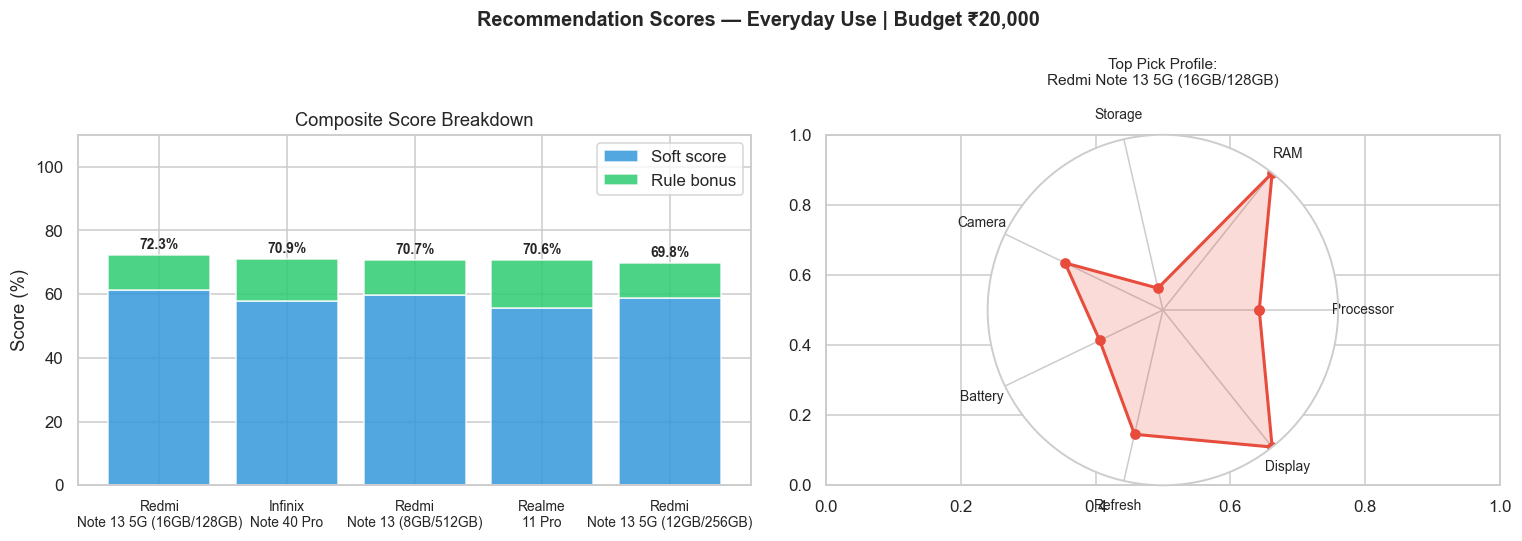

✅ Chart saved as recommendation_scores.png

📊 SPEC COMPARISON — Top 3 Recommendations
╭──────────────┬─────────────────────────────────┬───────────────────────┬─────────────────────────────╮
│ Attribute    │ Redmi Note 13 5G (16GB/128GB)   │ Infinix Note 40 Pro   │ Redmi Note 13 (8GB/512GB)   │
├──────────────┼─────────────────────────────────┼───────────────────────┼─────────────────────────────┤
│ Price        │ ₹19,972                         │ ₹17,999               │ ₹19,752                     │
│ RAM          │ 16GB                            │ 8GB                   │ 8GB                         │
│ Storage      │ 128GB                           │ 256GB                 │ 512GB                       │
│ Processor    │ Snapdragon 4 Gen 2              │ Helio G99 Ultimate    │ Snapdragon 6 Gen 1          │
│ Battery      │ 5,000mAh                        │ 5,000mAh              │ 5,000mAh                    │
│ Rear Camera  │ 108MP                           │ 108MP                 │

In [77]:
# ─────────────────────────────────────────────────────────────────────────────
#  ✏️  EDIT THIS CELL with YOUR own requirements and run it!
# ─────────────────────────────────────────────────────────────────────────────

MY_PREFS = {
    # ── Required ──────────────────────────────────────────────────────────────
    'currency'        : 'INR',       # 'INR'  or  'USD'
    'budget_inr'      : 20000,       # Max budget in ₹ (Indian market)
    'budget_usd'      : 400,         # Max budget in $ (Global market)
    'min_ram'         : 8,           # Minimum RAM in GB: 4 / 6 / 8 / 12
    'min_storage'     : 128,         # Minimum storage GB: 64 / 128 / 256 / 512

    # ── Connectivity ──────────────────────────────────────────────────────────
    'os'              : 'Any',       # 'Any' / 'Android' / 'iOS'
    'require_5g'      : False,       # True  or  False

    # ── Use Case (pick one) ───────────────────────────────────────────────────
    'use_case'        : 'Everyday Use',
    # Options: 'Everyday Use' | 'Gaming' | 'Photography' | 'Battery Life' | 'Business/Productivity'

    # ── Soft Priorities ───────────────────────────────────────────────────────
    'camera_priority' : 'Medium',    # 'Low' / 'Medium' / 'High'
    'battery_priority': 'Medium',    # 'Low' / 'Medium' / 'High'

    # ── Brand preferences ─────────────────────────────────────────────────────
    'brand'           : 'Any',
    # INR options: 'Any','Redmi','Samsung','POCO','Realme','OnePlus','Motorola','iQOO','Nothing','Vivo','Infinix'
    # USD options: 'Any','Samsung','Apple','Google','OnePlus','Nothing','Xiaomi','Motorola','POCO','Redmi','Realme'

    'proc_brand'      : 'Any',
    # Options: 'Any' / 'Qualcomm' / 'MediaTek' / 'Samsung' / 'Apple' / 'Google'
}

# ── Run & Display ─────────────────────────────────────────────────────────────
my_output = RS.recommend(MY_PREFS, top_n=5)
print_results(my_output, MY_PREFS, show_rules=True)
visualise_scores(my_output, MY_PREFS)
compare_specs(my_output, MY_PREFS, n=3)